Section 1 — Imports

# SolarPulse — Data Cleaning & Preparation

## Objective

This notebook performs exploratory data analysis, data-quality assessment,
cleaning, transformation, and feature engineering for the SolarPulse project.

The cleaned data will be used for:

1. Machine learning prediction of expected solar generation
2. Underperformance and anomaly detection
3. Power BI analytics

## Data Sources

- Solar generation data
- Weather data
- Solar site details
- Monthly solar summary

## Data Flow

Raw MySQL Tables
        ↓
Data Exploration
        ↓
Data Cleaning
        ↓
Data Validation
        ↓
Feature Engineering
        ↓
Clean Analytical Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import text

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


Section 2 — Database Connection

In [2]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from python.database import engine

print("MySQL connection ready.")

Database connection created successfully.
MySQL connection ready.


Section 3 — Load ALL Four Tables

In [3]:
sites = pd.read_sql(
    "SELECT * FROM solar_sites",
    engine
)

print(f"Shape: {sites.shape}")
display(sites.head())

Shape: (42, 10)


,CampusKey,SiteKey,kWp,Number_of_Panels,Panel,Inverter,Optimizers,Metric,Latitude,Longitude
0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,-36.111,146.849
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,-36.111,146.849
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,-36.111,146.849
3,2,4,NaN,NaN,NaN,NaN,NaN,NaN,-36.111,146.849
4,2,5,NaN,NaN,NaN,NaN,NaN,NaN,-36.111,146.849


In [4]:
weather = pd.read_sql(
    """
    SELECT
        CampusKey,
        Timestamp,
        ApparentTemperature,
        AirTemperature,
        DewPointTemperature,
        RelativeHumidity,
        WindSpeed,
        WindDirection
    FROM weather_raw
    """,
    engine
)

print(f"Shape: {weather.shape}")
display(weather.head())

Shape: (371769, 8)


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,1,2020-01-01 00:00:00,13.667,13.880,8.960,72.400,0.000,188.133
1,1,2020-01-01 00:15:00,13.207,13.667,9.040,73.467,1.200,203.867
2,1,2020-01-01 00:30:00,12.840,13.553,9.053,74.000,2.520,222.800
3,1,2020-01-01 00:45:00,12.113,13.507,9.100,74.467,5.987,231.133
4,1,2020-01-01 01:00:00,11.947,13.260,9.267,76.533,5.947,247.867


In [5]:
generation = pd.read_sql(
    """
    SELECT
        CampusKey,
        SiteKey,
        Timestamp,
        SolarGeneration
    FROM generation_raw
    """,
    engine
)

print(f"Shape: {generation.shape}")
display(generation.head())

Shape: (2731946, 4)


,CampusKey,SiteKey,Timestamp,SolarGeneration
0,2,1,2020-01-01 00:15:00,NaN
1,2,1,2020-01-01 00:30:00,NaN
2,2,1,2020-01-01 00:45:00,NaN
3,2,1,2020-01-01 01:00:00,NaN
4,2,1,2020-01-01 01:15:00,NaN


In [6]:
monthly_summary = pd.read_sql(
    """
    SELECT
        SiteKey,
        Year,
        DataStatus,
        AverageSolarGeneration,
        MaxSolarGeneration,
        MinSolarGeneration
    FROM monthly_summary
    """,
    engine
)

print("Monthly Summary")
print("=" * 50)
print("Shape:", monthly_summary.shape)

display(monthly_summary.head())

Monthly Summary
Shape: (1176, 6)


,SiteKey,Year,DataStatus,AverageSolarGeneration,MaxSolarGeneration,MinSolarGeneration
0,1,2020,1,10.157,21.778,0.101
1,2,2020,1,8.537,18.553,0.100
2,3,2020,1,6.310,13.322,0.103
3,4,2020,0,NaN,NaN,NaN
4,5,2020,0,NaN,NaN,NaN


Section 4 — Dataset Overview

In [7]:
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Solar Sites       : {len(sites):,}")
print(f"Generation Rows   : {len(generation):,}")
print(f"Weather Rows      : {len(weather):,}")
print(f"Monthly Rows      : {len(monthly_summary):,}")

DATASET OVERVIEW
Solar Sites       : 42
Generation Rows   : 2,731,946
Weather Rows      : 371,769
Monthly Rows      : 1,176


Section 5 — Data Types

In [8]:
print("GENERATION DATA TYPES")
print("=" * 60)

generation.info()

GENERATION DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 2731946 entries, 0 to 2731945
Data columns (total 4 columns):
 #   Column           Dtype         
---  ------           -----         
 0   CampusKey        int64         
 1   SiteKey          int64         
 2   Timestamp        datetime64[us]
 3   SolarGeneration  float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 83.4 MB


In [9]:
print("WEATHER DATA TYPES")
print("=" * 60)

weather.info()

WEATHER DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 371769 entries, 0 to 371768
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   CampusKey            371769 non-null  int64         
 1   Timestamp            371769 non-null  datetime64[us]
 2   ApparentTemperature  264656 non-null  float64       
 3   AirTemperature       264656 non-null  float64       
 4   DewPointTemperature  264656 non-null  float64       
 5   RelativeHumidity     264656 non-null  float64       
 6   WindSpeed            208879 non-null  float64       
 7   WindDirection        208879 non-null  float64       
dtypes: datetime64[us](1), float64(6), int64(1)
memory usage: 22.7 MB


In [10]:
print("SITE DATA TYPES")
print("=" * 60)

sites.info()

SITE DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CampusKey         42 non-null     int64  
 1   SiteKey           42 non-null     int64  
 2   kWp               25 non-null     float64
 3   Number_of_Panels  25 non-null     float64
 4   Panel             25 non-null     str    
 5   Inverter          25 non-null     str    
 6   Optimizers        23 non-null     str    
 7   Metric            25 non-null     str    
 8   Latitude          42 non-null     float64
 9   Longitude         42 non-null     float64
dtypes: float64(4), int64(2), str(4)
memory usage: 4.6 KB


In [11]:
print("MONTHLY SUMMARY DATA TYPES")
print("=" * 60)

monthly_summary.info()

MONTHLY SUMMARY DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SiteKey                 1176 non-null   int64  
 1   Year                    1176 non-null   int64  
 2   DataStatus              1176 non-null   int64  
 3   AverageSolarGeneration  976 non-null    float64
 4   MaxSolarGeneration      976 non-null    float64
 5   MinSolarGeneration      976 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 55.3 KB


Section 6 — Basic Statistics

In [12]:
generation.describe(include="all")

,CampusKey,SiteKey,Timestamp,SolarGeneration
count,"2,731,946.000","2,731,946.000",2731946,"1,195,645.000"
mean,1.706,21.695,2021-05-05 00:27:30.469225,6.944
min,1.000,1.000,2020-01-01 00:15:00,0.100
25%,1.000,11.000,2020-11-14 17:30:00,1.129
50%,1.000,22.000,2021-05-16 02:30:00,3.328
75%,2.000,33.000,2021-11-04 07:30:00,8.062
max,5.000,42.000,2022-04-23 23:45:00,99.219
std,1.054,12.310,NaN,11.203


In [13]:
weather.describe(include="all")

,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
count,"371,769.000",371769,"264,656.000","264,656.000","264,656.000","264,656.000","208,879.000","208,879.000"
mean,2.821,2021-03-20 05:20:21.744147,13.650,15.938,8.674,68.011,11.009,182.316
min,1.000,2020-01-01 00:00:00,-6.633,-2.707,-11.473,3.067,0.000,0.000
25%,2.000,2020-08-30 00:45:00,8.000,10.640,5.613,50.000,5.893,120.600
50%,3.000,2021-04-01 16:00:00,12.827,15.127,8.327,70.000,10.400,183.467
75%,4.000,2021-10-12 07:00:00,18.893,20.573,11.513,89.933,15.660,251.867
max,5.000,2022-04-23 22:00:00,41.587,45.400,25.320,100.000,56.400,358.067
std,1.337,NaN,7.593,7.381,4.439,24.061,7.383,88.439


In [14]:
sites.describe(include="all")

,CampusKey,SiteKey,kWp,Number_of_Panels,Panel,Inverter,Optimizers,Metric,Latitude,Longitude
count,42.000,42.000,25.000,25.000,25,25,23,25,42.000,42.000
unique,NaN,NaN,NaN,NaN,4,17,22,1,NaN,NaN
top,NaN,NaN,NaN,NaN,Trina 330W,1 x SolarEdge SE82.8K,61 x P730,kWh,NaN,NaN
freq,NaN,NaN,NaN,NaN,16,5,2,25,NaN,NaN
mean,1.667,21.500,90.860,263.160,NaN,NaN,NaN,NaN,-37.233,145.062
std,1.028,12.268,117.816,296.966,NaN,NaN,NaN,NaN,0.768,0.842
min,1.000,1.000,21.390,69.000,NaN,NaN,NaN,NaN,-37.718,142.167
25%,1.000,11.250,39.270,119.000,NaN,NaN,NaN,NaN,-37.718,145.051
50%,1.000,21.500,51.150,155.000,NaN,NaN,NaN,NaN,-37.718,145.051
75%,2.000,31.750,77.220,234.000,NaN,NaN,NaN,NaN,-36.779,145.051


In [15]:
monthly_summary.describe(include="all")

,SiteKey,Year,DataStatus,AverageSolarGeneration,MaxSolarGeneration,MinSolarGeneration
count,"1,176.000","1,176.000","1,176.000",976.000,976.000,976.000
mean,21.500,"2,020.714",0.830,6.552,16.934,0.109
std,12.126,0.700,0.376,7.565,19.665,0.012
min,1.000,"2,020.000",0.000,0.468,1.207,0.100
25%,11.000,"2,020.000",1.000,2.529,6.543,0.102
50%,21.500,"2,021.000",1.000,4.388,12.043,0.102
75%,32.000,"2,021.000",1.000,7.015,17.709,0.113
max,42.000,"2,022.000",1.000,43.907,99.219,0.321


Section 7 — Missing Values

In [16]:
generation_missing = generation.isnull().sum()

print("Generation Missing Values")
display(
    generation_missing.to_frame("Missing_Count")
)

Generation Missing Values


,Missing_Count
CampusKey,0
SiteKey,0
Timestamp,0
SolarGeneration,1536301


In [17]:
generation_missing_pct = (
    generation.isnull().mean() * 100
).round(2)

print("Generation Missing Percentage")
display(
    generation_missing_pct.to_frame("Missing_Percentage")
)

Generation Missing Percentage


,Missing_Percentage
CampusKey,0.000
SiteKey,0.000
Timestamp,0.000
SolarGeneration,56.230


In [18]:
weather_missing = weather.isnull().sum()

print("Weather Missing Values")
display(
    weather_missing.to_frame("Missing_Count")
)

Weather Missing Values


,Missing_Count
CampusKey,0
Timestamp,0
ApparentTemperature,107113
AirTemperature,107113
DewPointTemperature,107113
RelativeHumidity,107113
WindSpeed,162890
WindDirection,162890


In [19]:
weather_missing_pct = (
    weather.isnull().mean() * 100
).round(2)

print("Weather Missing Percentage")
display(
    weather_missing_pct.to_frame("Missing_Percentage")
)

Weather Missing Percentage


,Missing_Percentage
CampusKey,0.000
Timestamp,0.000
ApparentTemperature,28.810
AirTemperature,28.810
DewPointTemperature,28.810
RelativeHumidity,28.810
WindSpeed,43.810
WindDirection,43.810


In [20]:
sites_missing = sites.isnull().sum()

print("Site Metadata Missing Values")
display(
    sites_missing.to_frame("Missing_Count")
)

Site Metadata Missing Values


,Missing_Count
CampusKey,0
SiteKey,0
kWp,17
Number_of_Panels,17
Panel,17
Inverter,17
Optimizers,19
Metric,17
Latitude,0
Longitude,0


In [21]:
monthly_missing = monthly_summary.isnull().sum()

print("Monthly Summary Missing Values")
display(
    monthly_missing.to_frame("Missing_Count")
)

Monthly Summary Missing Values


,Missing_Count
SiteKey,0
Year,0
DataStatus,0
AverageSolarGeneration,200
MaxSolarGeneration,200
MinSolarGeneration,200


Section 8 — Visualize Missing Values

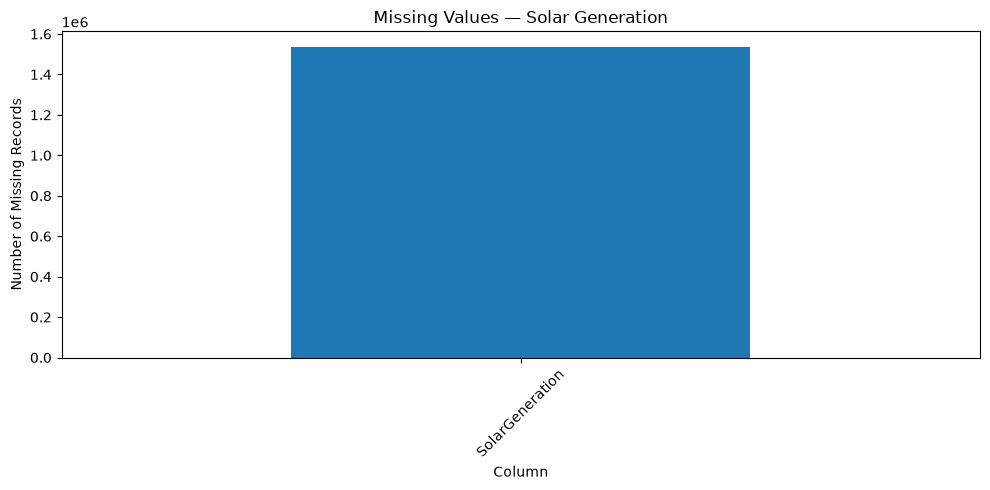

In [22]:
plt.figure(figsize=(10, 5))

generation_missing[
    generation_missing > 0
].sort_values().plot(
    kind="bar"
)

plt.title("Missing Values — Solar Generation")
plt.ylabel("Number of Missing Records")
plt.xlabel("Column")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

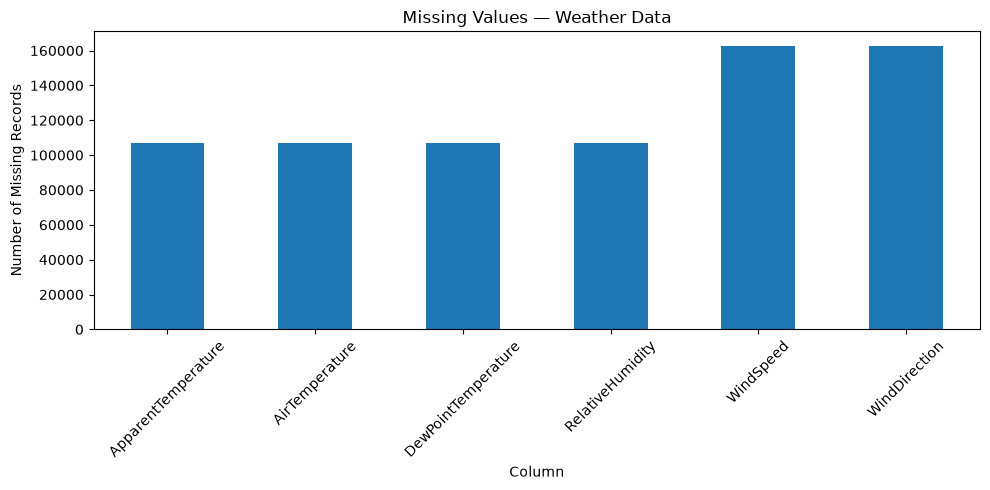

In [23]:
plt.figure(figsize=(10, 5))

weather_missing[
    weather_missing > 0
].sort_values().plot(
    kind="bar"
)

plt.title("Missing Values — Weather Data")
plt.ylabel("Number of Missing Records")
plt.xlabel("Column")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Section 9 — Duplicate Analysis

In [24]:
generation_duplicates = generation.duplicated(
    subset=["SiteKey", "Timestamp"]
).sum()

weather_duplicates = weather.duplicated(
    subset=["CampusKey", "Timestamp"]
).sum()

print(
    f"Duplicate generation records: "
    f"{generation_duplicates:,}"
)

print(
    f"Duplicate weather records: "
    f"{weather_duplicates:,}"
)

Duplicate generation records: 0
Duplicate weather records: 0


Section 10 — Validity Checks

In [25]:
print(
    "Negative generation:",
    (generation["SolarGeneration"] < 0).sum()
)

print(
    "Zero generation:",
    (generation["SolarGeneration"] == 0).sum()
)

print(
    "Invalid humidity:",
    (
        (weather["RelativeHumidity"] < 0) |
        (weather["RelativeHumidity"] > 100)
    ).sum()
)

print(
    "Invalid wind direction:",
    (
        (weather["WindDirection"] < 0) |
        (weather["WindDirection"] > 360)
    ).sum()
)

Negative generation: 0
Zero generation: 0
Invalid humidity: 0
Invalid wind direction: 0


Section 11 — Timestamp Processing

In [26]:
generation["Timestamp"] = pd.to_datetime(
    generation["Timestamp"],
    errors="coerce"
)

weather["Timestamp"] = pd.to_datetime(
    weather["Timestamp"],
    errors="coerce"
)

print(
    "Generation timestamp:",
    generation["Timestamp"].dtype
)

print(
    "Weather timestamp:",
    weather["Timestamp"].dtype
)

Generation timestamp: datetime64[us]
Weather timestamp: datetime64[us]


Section 12 — Check Date Ranges

In [27]:
print("Generation Date Range")
print("-" * 40)

print("Start:", generation["Timestamp"].min())
print("End  :", generation["Timestamp"].max())

print("\nWeather Date Range")
print("-" * 40)

print("Start:", weather["Timestamp"].min())
print("End  :", weather["Timestamp"].max())

Generation Date Range
----------------------------------------
Start: 2020-01-01 00:15:00
End  : 2022-04-23 23:45:00

Weather Date Range
----------------------------------------
Start: 2020-01-01 00:00:00
End  : 2022-04-23 22:00:00


Section 13 — Sort Data

In [28]:
generation = generation.sort_values(
    ["SiteKey", "Timestamp"]
).reset_index(drop=True)

weather = weather.sort_values(
    ["CampusKey", "Timestamp"]
).reset_index(drop=True)

print("Generation and weather data sorted successfully.")

Generation and weather data sorted successfully.


Section 14 — Missing Weather Over Time

In [29]:
weather_daily_missing = (
    weather
    .set_index("Timestamp")
    .isnull()
    .resample("D")
    .sum()
)

display(
    weather_daily_missing.head(10)
)

,CampusKey,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
Timestamp,,,,,,,
2020-01-01,0,0,0,0,0,0,0
2020-01-02,0,0,0,0,0,0,0
2020-01-03,0,0,0,0,0,0,0
2020-01-04,0,0,0,0,0,0,0
2020-01-05,0,0,0,0,0,0,0
2020-01-06,0,0,0,0,0,0,0
2020-01-07,0,0,0,0,0,0,0
2020-01-08,0,0,0,0,0,0,0
2020-01-09,0,0,0,0,0,0,0


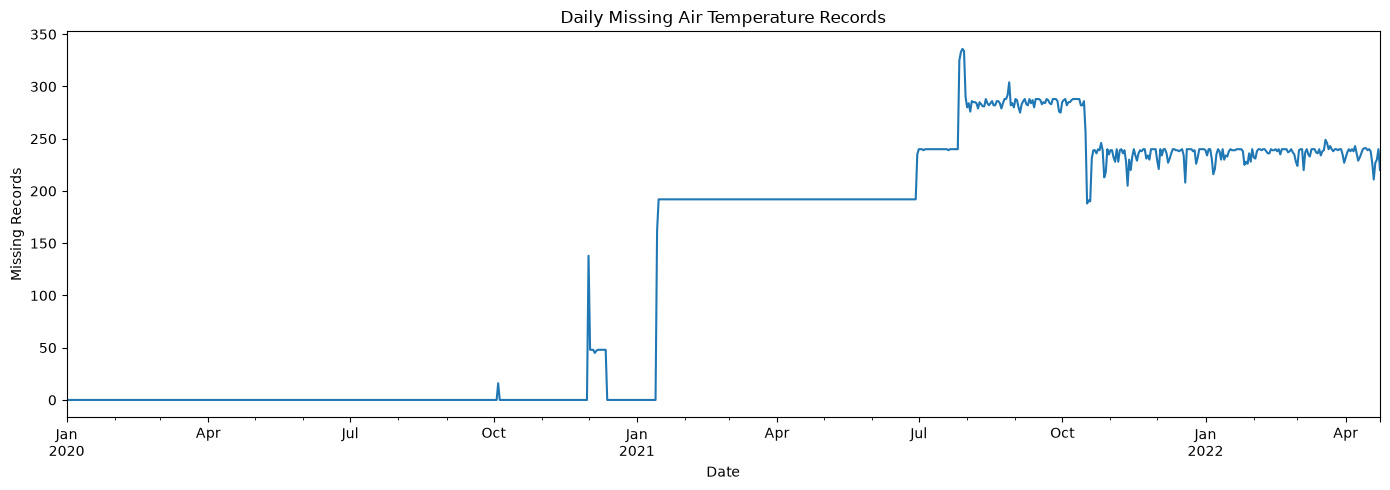

In [30]:
plt.figure(figsize=(14, 5))

weather_daily_missing["AirTemperature"].plot()

plt.title("Daily Missing Air Temperature Records")
plt.ylabel("Missing Records")
plt.xlabel("Date")

plt.tight_layout()
plt.show()

Section 15 — Generation Missingness by Site

In [31]:
generation_site_quality = (
    generation
    .groupby("SiteKey")
    .agg(
        total_records=("SolarGeneration", "size"),
        valid_records=("SolarGeneration", "count"),
        missing_records=(
            "SolarGeneration",
            lambda x: x.isna().sum()
        )
    )
)

generation_site_quality["missing_percentage"] = (
    generation_site_quality["missing_records"]
    / generation_site_quality["total_records"]
    * 100
)

display(
    generation_site_quality
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

,total_records,valid_records,missing_records,missing_percentage
SiteKey,,,,
7,79319,20192,59127,74.543
5,47215,17969,29246,61.942
9,79319,30994,48325,60.925
35,72604,29233,43371,59.736
29,60403,24680,35723,59.141
28,59948,24512,35436,59.111
13,77303,31630,45673,59.083
4,47215,19477,27738,58.748
16,47124,19547,27577,58.520


In [32]:
generation_times = (
    generation["Timestamp"]
    .sort_values()
    .drop_duplicates()
)

weather_times = (
    weather["Timestamp"]
    .sort_values()
    .drop_duplicates()
)

print("Generation timestamp differences:")
display(
    generation_times.diff()
    .value_counts()
    .head(10)
)

print("\nWeather timestamp differences:")
display(
    weather_times.diff()
    .value_counts()
    .head(10)
)

Generation timestamp differences:


Timestamp
0 days 00:15:00    79994
0 days 01:15:00        2
0 days 22:00:00        1
1 days 06:30:00        1
0 days 09:00:00        1
1 days 23:00:00        1
0 days 19:00:00        1
1 days 03:30:00        1
0 days 01:30:00        1
1 days 03:00:00        1
Name: count, dtype: int64


Weather timestamp differences:


Timestamp
0 days 00:15:00    81016
Name: count, dtype: int64

In [33]:
generation_timestamp_set = set(
    generation["Timestamp"].drop_duplicates()
)

weather_timestamp_set = set(
    weather["Timestamp"].drop_duplicates()
)

common_timestamps = (
    generation_timestamp_set
    .intersection(weather_timestamp_set)
)

print(
    "Unique generation timestamps:",
    len(generation_timestamp_set)
)

print(
    "Unique weather timestamps:",
    len(weather_timestamp_set)
)

print(
    "Common timestamps:",
    len(common_timestamps)
)

print(
    "Generation timestamps with weather match:",
    len(common_timestamps)
    / len(generation_timestamp_set)
    * 100
)

Unique generation timestamps: 80007
Unique weather timestamps: 81017
Common timestamps: 80000
Generation timestamps with weather match: 99.99125076555802


In [34]:
generation["Hour"] = generation["Timestamp"].dt.hour

hourly_generation_quality = (
    generation
    .groupby("Hour")
    .agg(
        total_records=("SolarGeneration", "size"),
        valid_records=("SolarGeneration", "count"),
        missing_records=(
            "SolarGeneration",
            lambda x: x.isna().sum()
        )
    )
)

hourly_generation_quality["missing_percentage"] = (
    hourly_generation_quality["missing_records"]
    / hourly_generation_quality["total_records"]
    * 100
)

display(hourly_generation_quality)

,total_records,valid_records,missing_records,missing_percentage
Hour,,,,
0,114089,39,114050,99.966
1,114494,47,114447,99.959
2,114356,31,114325,99.973
3,114492,28,114464,99.976
4,114470,32,114438,99.972
5,114326,29,114297,99.975
6,114272,10381,103891,90.916
7,114236,57940,56296,49.280
8,114071,99386,14685,12.874


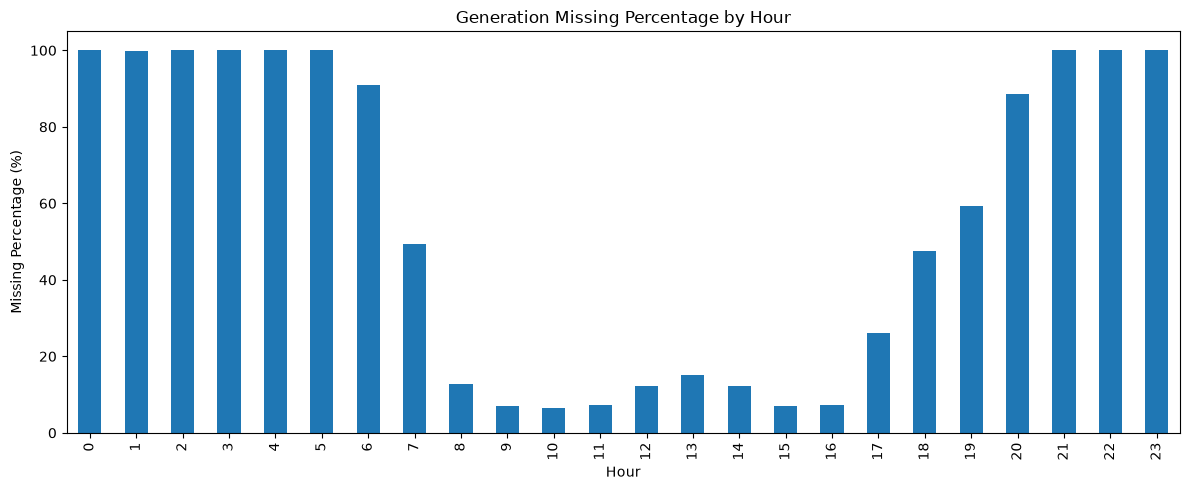

In [35]:
plt.figure(figsize=(12, 5))

hourly_generation_quality[
    "missing_percentage"
].plot(kind="bar")

plt.title(
    "Generation Missing Percentage by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Missing Percentage (%)")

plt.tight_layout()
plt.show()

##### Section 16 — Data Cleaning

## Cleaning Strategy

The raw data is preserved in MySQL and is not modified.

Cleaning is performed in Pandas on copies of the raw datasets.

### Solar Generation

- Convert and validate timestamps
- Remove duplicate site/timestamp observations
- Validate physical ranges
- Investigate missingness by time and site
- Do not impute missing generation values
- Retain missing target values for data-quality analysis
- Exclude missing targets from supervised ML training

### Weather

- Convert numeric columns
- Preserve original missing-value indicators
- Interpolate short temporal gaps
- Use campus/time-based statistics for longer gaps
- Validate physical ranges
- Preserve statistically unusual but physically plausible observations

### Site Metadata

- Preserve valid metadata
- Do not fabricate missing equipment/capacity information

In [36]:
generation_clean = generation.copy()
weather_clean = weather.copy()
sites_clean = sites.copy()

In [37]:
print("Generation shape:", generation_clean.shape)
print("Weather shape:", weather_clean.shape)
print("Sites shape:", sites_clean.shape)

Generation shape: (2731946, 5)
Weather shape: (371769, 8)
Sites shape: (42, 10)


Clean generation timestamps

In [38]:
generation_clean["Timestamp"] = pd.to_datetime(
    generation_clean["Timestamp"],
    errors="coerce"
)

invalid_timestamps = (
    generation_clean["Timestamp"].isna().sum()
)

print(
    "Invalid generation timestamps:",
    invalid_timestamps
)

Invalid generation timestamps: 0


Clean generation timestamps

In [39]:
generation_clean["Timestamp"] = pd.to_datetime(
    generation_clean["Timestamp"],
    errors="coerce"
)

invalid_timestamps = (
    generation_clean["Timestamp"].isna().sum()
)

print(
    "Invalid generation timestamps:",
    invalid_timestamps
)

Invalid generation timestamps: 0


Validate generation values

In [40]:
negative_generation = (
    generation_clean["SolarGeneration"] < 0
).sum()

zero_generation = (
    generation_clean["SolarGeneration"] == 0
).sum()

print("Negative generation:", negative_generation)
print("Zero generation:", zero_generation)

Negative generation: 0
Zero generation: 0


Identify the production period

In [41]:
generation_clean["Hour"] = (
    generation_clean["Timestamp"].dt.hour
)

generation_clean["IsProductionPeriod"] = (
    generation_clean["Hour"].between(7, 20)
).astype(int)

generation_clean[
    ["Timestamp", "Hour", "IsProductionPeriod"]
].head()

,Timestamp,Hour,IsProductionPeriod
0,2020-01-01 00:15:00,0,0
1,2020-01-01 00:30:00,0,0
2,2020-01-01 00:45:00,0,0
3,2020-01-01 01:00:00,1,0
4,2020-01-01 01:15:00,1,0


## Generation Missing Values

A large proportion of SolarGeneration values are missing.

The hourly analysis shows that missingness is strongly concentrated outside the main production period.

Therefore, missing generation values will NOT be replaced with zero.

For supervised ML, SolarGeneration is the target variable. A row without an observed target cannot be used to train the regression model.

Missing generation rows are retained for data-quality analysis but excluded from model training.

In [42]:
generation_clean["GenerationWasMissing"] = (
    generation_clean["SolarGeneration"].isna()
).astype(int)

print(
    "Missing generation:",
    generation_clean["GenerationWasMissing"].sum()
)

Missing generation: 1536301


Clean weather timestamps

In [43]:
weather_clean["Timestamp"] = pd.to_datetime(
    weather_clean["Timestamp"],
    errors="coerce"
)

print(
    "Invalid weather timestamps:",
    weather_clean["Timestamp"].isna().sum()
)

Invalid weather timestamps: 0


Preserve weather missing indicators

In [44]:
weather_columns = [
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",
    "WindDirection"
]

for col in weather_columns:
    weather_clean[f"{col}_WasMissing"] = (
        weather_clean[col].isna()
    ).astype(int)

In [45]:
display(
    weather_clean[
        [f"{col}_WasMissing" for col in weather_columns]
    ].sum().to_frame("Original_Missing_Count")
)

,Original_Missing_Count
ApparentTemperature_WasMissing,107113
AirTemperature_WasMissing,107113
DewPointTemperature_WasMissing,107113
RelativeHumidity_WasMissing,107113
WindSpeed_WasMissing,162890
WindDirection_WasMissing,162890


Sort weather data

In [46]:
weather_clean = weather_clean.sort_values(
    ["CampusKey", "Timestamp"]
).reset_index(drop=True)

Weather domain validation

In [47]:
invalid_humidity = (
    (weather_clean["RelativeHumidity"] < 0) |
    (weather_clean["RelativeHumidity"] > 100)
)

invalid_wind_direction = (
    (weather_clean["WindDirection"] < 0) |
    (weather_clean["WindDirection"] > 360)
)

invalid_wind_speed = (
    weather_clean["WindSpeed"] < 0
)

print(
    "Invalid humidity:",
    invalid_humidity.sum()
)

print(
    "Invalid wind direction:",
    invalid_wind_direction.sum()
)

print(
    "Negative wind speed:",
    invalid_wind_speed.sum()
)

Invalid humidity: 0
Invalid wind direction: 0
Negative wind speed: 0


Short-gap weather interpolation

In [48]:
for col in weather_columns:

    weather_clean[col] = (
        weather_clean
        .groupby("CampusKey")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=4,
                limit_direction="both"
            )
        )
    )

In [49]:
remaining_missing = (
    weather_clean[weather_columns]
    .isna()
    .sum()
)

display(
    remaining_missing.to_frame(
        "Missing_After_Interpolation"
    )
)

,Missing_After_Interpolation
ApparentTemperature,53404
AirTemperature,53404
DewPointTemperature,53404
RelativeHumidity,53404
WindSpeed,162818
WindDirection,162818


Handle long weather gaps

In [50]:
weather_clean["Month"] = (
    weather_clean["Timestamp"].dt.month
)

weather_clean["Hour"] = (
    weather_clean["Timestamp"].dt.hour
)

In [51]:
for col in weather_columns:

    group_median = (
        weather_clean
        .groupby(
            ["CampusKey", "Month", "Hour"]
        )[col]
        .transform("median")
    )

    weather_clean[col] = (
        weather_clean[col]
        .fillna(group_median)
    )

Final fallback

In [52]:
for col in weather_columns:

    campus_median = (
        weather_clean
        .groupby("CampusKey")[col]
        .transform("median")
    )

    weather_clean[col] = (
        weather_clean[col]
        .fillna(campus_median)
    )

In [53]:
final_weather_missing = (
    weather_clean[weather_columns]
    .isna()
    .sum()
)

display(
    final_weather_missing.to_frame(
        "Final_Missing_Count"
    )
)

,Final_Missing_Count
ApparentTemperature,0
AirTemperature,0
DewPointTemperature,0
RelativeHumidity,0
WindSpeed,0
WindDirection,0


Check that we didn't create impossible values

In [54]:
print(
    "Humidity outside 0–100:",
    (
        (weather_clean["RelativeHumidity"] < 0) |
        (weather_clean["RelativeHumidity"] > 100)
    ).sum()
)

print(
    "Negative wind speed:",
    (
        weather_clean["WindSpeed"] < 0
    ).sum()
)

print(
    "Wind direction outside 0–360:",
    (
        (weather_clean["WindDirection"] < 0) |
        (weather_clean["WindDirection"] > 360)
    ).sum()
)

Humidity outside 0–100: 0
Negative wind speed: 0
Wind direction outside 0–360: 0


Wind direction transformation

In [55]:
weather_clean["WindDirection_sin"] = np.sin(
    np.radians(weather_clean["WindDirection"])
)

weather_clean["WindDirection_cos"] = np.cos(
    np.radians(weather_clean["WindDirection"])
)

Create proper generation time features

In [56]:
generation_clean["Minute"] = (
    generation_clean["Timestamp"].dt.minute
)

generation_clean["Day"] = (
    generation_clean["Timestamp"].dt.day
)

generation_clean["Month"] = (
    generation_clean["Timestamp"].dt.month
)

generation_clean["Year"] = (
    generation_clean["Timestamp"].dt.year
)

generation_clean["DayOfWeek"] = (
    generation_clean["Timestamp"].dt.dayofweek
)

generation_clean["DayOfYear"] = (
    generation_clean["Timestamp"].dt.dayofyear
)

generation_clean["IsWeekend"] = (
    generation_clean["DayOfWeek"] >= 5
).astype(int)

Cyclical time features

In [57]:
generation_clean["Hour_sin"] = np.sin(
    2 * np.pi * generation_clean["Hour"] / 24
)

generation_clean["Hour_cos"] = np.cos(
    2 * np.pi * generation_clean["Hour"] / 24
)

generation_clean["DayOfYear_sin"] = np.sin(
    2 * np.pi *
    generation_clean["DayOfYear"] / 365
)

generation_clean["DayOfYear_cos"] = np.cos(
    2 * np.pi *
    generation_clean["DayOfYear"] / 365
)

Join generation + weather

In [58]:
model_data = generation_clean.merge(
    weather_clean,
    on=["CampusKey", "Timestamp"],
    how="left",
    suffixes=("", "_weather")
)

In [59]:
print("Generation rows:", len(generation_clean))
print("Merged rows    :", len(model_data))
print("Merged shape   :", model_data.shape)

Generation rows: 2731946
Merged rows    : 2731946
Merged shape   : (2731946, 34)


Add site information

In [60]:
site_features = sites_clean[
    [
        "CampusKey",
        "SiteKey",
        "kWp",
        "Number_of_Panels",
        "Latitude",
        "Longitude"
    ]
].copy()

In [61]:
site_features = sites_clean[
    [
        "CampusKey",
        "SiteKey",
        "kWp",
        "Number_of_Panels",
        "Latitude",
        "Longitude"
    ]
].copy()

In [62]:
print("Final integrated dataset:")
print(model_data.shape)

display(model_data.head())

Final integrated dataset:
(2731946, 34)


,CampusKey,SiteKey,Timestamp,SolarGeneration,Hour,IsProductionPeriod,GenerationWasMissing,Minute,Day,Month,Year,DayOfWeek,DayOfYear,IsWeekend,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,ApparentTemperature_WasMissing,AirTemperature_WasMissing,DewPointTemperature_WasMissing,RelativeHumidity_WasMissing,WindSpeed_WasMissing,WindDirection_WasMissing,Month_weather,Hour_weather,WindDirection_sin,WindDirection_cos
0,2,1,2020-01-01 00:15:00,NaN,0,0,1,15,1,1,2020,2,1,0,0.000,1.000,0.017,1.000,18.560,20.300,9.600,50.267,8.680,152.667,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.459,-0.888
1,2,1,2020-01-01 00:30:00,NaN,0,0,1,30,1,1,2020,2,1,0,0.000,1.000,0.017,1.000,18.147,19.840,9.340,50.667,7.933,157.533,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.382,-0.924
2,2,1,2020-01-01 00:45:00,NaN,0,0,1,45,1,1,2020,2,1,0,0.000,1.000,0.017,1.000,18.140,19.887,9.487,51.000,8.440,147.600,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.536,-0.844
3,2,1,2020-01-01 01:00:00,NaN,1,0,1,0,1,1,2020,2,1,0,0.259,0.966,0.017,1.000,17.693,19.540,9.180,51.133,8.680,151.333,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.480,-0.877
4,2,1,2020-01-01 01:15:00,NaN,1,0,1,15,1,1,2020,2,1,0,0.259,0.966,0.017,1.000,17.613,19.153,9.053,51.933,6.867,149.333,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.510,-0.860


Create the ML dataset

In [63]:
ml_data = model_data[
    model_data["SolarGeneration"].notna()
].copy()

print(
    "Rows available for ML:",
    f"{len(ml_data):,}"
)

print(
    "Rows excluded because target was missing:",
    f"{len(model_data) - len(ml_data):,}"
)

Rows available for ML: 1,195,645
Rows excluded because target was missing: 1,536,301


Final ML missing-value check

In [64]:
ml_missing = (
    ml_data.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    ml_missing.head(20).to_frame(
        "Missing_Count"
    )
)

,Missing_Count
WindDirection_sin,14147
WindDirection_cos,14147
AirTemperature_WasMissing,14147
ApparentTemperature_WasMissing,14147
Hour_weather,14147
Month_weather,14147
WindDirection_WasMissing,14147
WindSpeed_WasMissing,14147
RelativeHumidity_WasMissing,14147
DewPointTemperature_WasMissing,14147


Outlier analysis: Weather

In [65]:
weather_outlier_columns = [
    "AirTemperature",
    "ApparentTemperature",
    "DewPointTemperature",
    "WindSpeed"
]

for col in weather_outlier_columns:

    Q1 = weather_clean[col].quantile(0.25)
    Q3 = weather_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    weather_clean[f"{col}_Outlier"] = (
        (weather_clean[col] < lower) |
        (weather_clean[col] > upper)
    ).astype(int)

    print(
        f"{col}: "
        f"lower={lower:.2f}, "
        f"upper={upper:.2f}, "
        f"outliers="
        f"{weather_clean[f'{col}_Outlier'].sum():,}"
    )

AirTemperature: lower=-2.84, upper=35.11, outliers=2,748
ApparentTemperature: lower=-6.97, upper=34.82, outliers=733
DewPointTemperature: lower=-2.69, upper=19.93, outliers=3,813
WindSpeed: lower=-3.56, upper=26.20, outliers=6,478


Generation outlier flag

In [66]:
Q1 = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .transform("quantile", 0.25)
)

Q3 = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .transform("quantile", 0.75)
)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ml_data["Generation_Outlier"] = (
    (ml_data["SolarGeneration"] < lower_bound) |
    (ml_data["SolarGeneration"] > upper_bound)
).astype(int)

print(
    "Generation statistical outliers:",
    f"{ml_data['Generation_Outlier'].sum():,}"
)

Generation statistical outliers: 0


Find unmatched generation rows

In [67]:
weather_keys = weather_clean[
    ["CampusKey", "Timestamp"]
].drop_duplicates()

merge_check = generation_clean.merge(
    weather_keys,
    on=["CampusKey", "Timestamp"],
    how="left",
    indicator=True
)

unmatched_rows = merge_check[
    merge_check["_merge"] == "left_only"
].copy()

print(
    "Generation rows without matching weather:",
    f"{len(unmatched_rows):,}"
)

display(
    unmatched_rows.head(20)
)

Generation rows without matching weather: 32,785


,CampusKey,SiteKey,Timestamp,SolarGeneration,Hour,IsProductionPeriod,GenerationWasMissing,Minute,Day,Month,Year,DayOfWeek,DayOfYear,IsWeekend,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,_merge
79312,2,1,2022-04-23 22:15:00,NaN,22,0,1,15,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only
79313,2,1,2022-04-23 22:30:00,NaN,22,0,1,30,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only
79314,2,1,2022-04-23 22:45:00,NaN,22,0,1,45,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only
79315,2,1,2022-04-23 23:00:00,NaN,23,0,1,0,23,4,2022,5,113,1,-0.259,0.966,0.931,-0.366,left_only
79316,2,1,2022-04-23 23:15:00,NaN,23,0,1,15,23,4,2022,5,113,1,-0.259,0.966,0.931,-0.366,left_only
79317,2,1,2022-04-23 23:30:00,NaN,23,0,1,30,23,4,2022,5,113,1,-0.259,0.966,0.931,-0.366,left_only
79318,2,1,2022-04-23 23:45:00,NaN,23,0,1,45,23,4,2022,5,113,1,-0.259,0.966,0.931,-0.366,left_only
158631,2,2,2022-04-23 22:15:00,NaN,22,0,1,15,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only
158632,2,2,2022-04-23 22:30:00,NaN,22,0,1,30,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only
158633,2,2,2022-04-23 22:45:00,NaN,22,0,1,45,23,4,2022,5,113,1,-0.500,0.866,0.931,-0.366,left_only


Check when those missing weather rows occur

In [68]:
unmatched_rows["Hour"] = (
    unmatched_rows["Timestamp"].dt.hour
)

display(
    unmatched_rows["Hour"]
    .value_counts()
    .sort_index()
    .to_frame("Unmatched_Rows")
)

,Unmatched_Rows
Hour,
0,1357
1,1356
2,1360
3,1360
4,1357
5,1356
6,1356
7,1355
8,1352


Check by campus

In [69]:
display(
    unmatched_rows["CampusKey"]
    .value_counts()
    .sort_index()
    .to_frame("Unmatched_Rows")
)

,Unmatched_Rows
CampusKey,
1,189
2,35
3,56
4,7
5,32498


Check by hour and campus

In [70]:
unmatched_summary = (
    unmatched_rows
    .groupby(["CampusKey", "Hour"])
    .size()
    .reset_index(name="Unmatched_Rows")
)

display(
    unmatched_summary
    .sort_values("Unmatched_Rows", ascending=False)
    .head(30)
)

,CampusKey,Hour,Unmatched_Rows
10,5,2,1360
11,5,3,1360
12,5,4,1357
8,5,0,1357
13,5,5,1356
14,5,6,1356
9,5,1,1356
25,5,17,1356
30,5,22,1355
15,5,7,1355


Generation and Weather Coverage by Campus

The previous timestamp analysis showed that most unmatched records
belong to Campus 5.

We therefore compare generation and weather coverage at the campus
level before deciding how unmatched observations should be treated.

In [71]:
generation_campus_summary = (
    generation_clean
    .groupby("CampusKey")
    .agg(
        generation_rows=("Timestamp", "size"),
        unique_timestamps=("Timestamp", "nunique"),
        first_timestamp=("Timestamp", "min"),
        last_timestamp=("Timestamp", "max")
    )
    .reset_index()
)

display(generation_campus_summary)

,CampusKey,generation_rows,unique_timestamps,first_timestamp,last_timestamp
0,1,1720219,79805,2020-01-01 00:15:00,2022-04-23 23:45:00
1,2,332387,79319,2020-01-01 00:15:00,2022-04-23 23:45:00
2,3,520702,79319,2020-01-01 00:15:00,2022-04-23 23:45:00
3,4,79319,79319,2020-01-01 00:15:00,2022-04-23 23:45:00
4,5,79319,79319,2020-01-01 00:15:00,2022-04-23 23:45:00


In [72]:
weather_campus_summary = (
    weather_clean
    .groupby("CampusKey")
    .agg(
        weather_rows=("Timestamp", "size"),
        unique_timestamps=("Timestamp", "nunique"),
        first_timestamp=("Timestamp", "min"),
        last_timestamp=("Timestamp", "max")
    )
    .reset_index()
)

display(weather_campus_summary)

,CampusKey,weather_rows,unique_timestamps,first_timestamp,last_timestamp
0,1,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
1,2,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
2,3,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
3,4,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
4,5,47701,47701,2020-12-13 01:00:00,2022-04-23 22:00:00


In [73]:
campus_coverage = generation_campus_summary.merge(
    weather_campus_summary,
    on="CampusKey",
    how="outer",
    suffixes=("_generation", "_weather")
)

display(campus_coverage)

,CampusKey,generation_rows,unique_timestamps_generation,first_timestamp_generation,last_timestamp_generation,weather_rows,unique_timestamps_weather,first_timestamp_weather,last_timestamp_weather
0,1,1720219,79805,2020-01-01 00:15:00,2022-04-23 23:45:00,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
1,2,332387,79319,2020-01-01 00:15:00,2022-04-23 23:45:00,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
2,3,520702,79319,2020-01-01 00:15:00,2022-04-23 23:45:00,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
3,4,79319,79319,2020-01-01 00:15:00,2022-04-23 23:45:00,81017,81017,2020-01-01 00:00:00,2022-04-23 22:00:00
4,5,79319,79319,2020-01-01 00:15:00,2022-04-23 23:45:00,47701,47701,2020-12-13 01:00:00,2022-04-23 22:00:00


In [74]:
print("Campus 5 Generation")
print("=" * 50)

display(
    generation_clean[
        generation_clean["CampusKey"] == 5
    ][
        ["SiteKey", "Timestamp", "SolarGeneration"]
    ].head(20)
)

print("\nCampus 5 Weather")
print("=" * 50)

display(
    weather_clean[
        weather_clean["CampusKey"] == 5
    ].head(20)
)

Campus 5 Generation


,SiteKey,Timestamp,SolarGeneration
2652627,42,2020-01-01 00:15:00,NaN
2652628,42,2020-01-01 00:30:00,NaN
2652629,42,2020-01-01 00:45:00,NaN
2652630,42,2020-01-01 01:00:00,NaN
2652631,42,2020-01-01 01:15:00,NaN
2652632,42,2020-01-01 01:30:00,NaN
2652633,42,2020-01-01 01:45:00,NaN
2652634,42,2020-01-01 02:00:00,NaN
2652635,42,2020-01-01 02:15:00,NaN
2652636,42,2020-01-01 02:30:00,NaN



Campus 5 Weather


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,ApparentTemperature_WasMissing,AirTemperature_WasMissing,DewPointTemperature_WasMissing,RelativeHumidity_WasMissing,WindSpeed_WasMissing,WindDirection_WasMissing,Month,Hour,WindDirection_sin,WindDirection_cos,AirTemperature_Outlier,ApparentTemperature_Outlier,DewPointTemperature_Outlier,WindSpeed_Outlier
324068,5,2020-12-13 01:00:00,15.173,19.387,7.787,47.000,19.040,36.533,0,0,0,0,0,0,12,1,0.595,0.804,0,0,0,0
324069,5,2020-12-13 01:15:00,15.113,19.187,7.893,48.000,18.380,33.933,0,0,0,0,0,0,12,1,0.558,0.830,0,0,0,0
324070,5,2020-12-13 01:30:00,14.680,19.167,7.940,48.200,20.600,34.867,0,0,0,0,0,0,12,1,0.572,0.820,0,0,0,0
324071,5,2020-12-13 01:45:00,14.640,19.147,7.847,48.000,20.640,35.400,0,0,0,0,0,0,12,1,0.579,0.815,0,0,0,0
324072,5,2020-12-13 02:00:00,14.967,18.907,7.847,48.533,17.640,39.733,0,0,0,0,0,0,12,2,0.639,0.769,0,0,0,0
324073,5,2020-12-13 02:15:00,14.900,18.607,7.767,49.200,16.300,44.400,0,0,0,0,0,0,12,2,0.700,0.714,0,0,0,0
324074,5,2020-12-13 02:30:00,14.807,18.280,7.840,50.533,15.300,47.600,0,0,0,0,0,0,12,2,0.738,0.674,0,0,0,0
324075,5,2020-12-13 02:45:00,14.793,18.073,7.893,51.400,14.320,47.200,0,0,0,0,0,0,12,2,0.734,0.679,0,0,0,0
324076,5,2020-12-13 03:00:00,14.707,17.873,7.993,52.400,13.960,49.800,0,0,0,0,0,0,12,3,0.764,0.645,0,0,0,0
324077,5,2020-12-13 03:15:00,14.633,17.513,8.053,53.800,12.520,55.667,0,0,0,0,0,0,12,3,0.826,0.564,0,0,0,0


In [75]:
campus5_weather = weather_clean[
    weather_clean["CampusKey"] == 5
].copy()

campus5_generation = generation_clean[
    generation_clean["CampusKey"] == 5
].copy()

print(
    "Campus 5 generation rows:",
    f"{len(campus5_generation):,}"
)

print(
    "Campus 5 weather rows:",
    f"{len(campus5_weather):,}"
)

print(
    "Campus 5 weather unique timestamps:",
    f"{campus5_weather['Timestamp'].nunique():,}"
)

Campus 5 generation rows: 79,319
Campus 5 weather rows: 47,701
Campus 5 weather unique timestamps: 47,701


In [76]:
campus5_generation_times = set(
    campus5_generation["Timestamp"]
)

campus5_weather_times = set(
    campus5_weather["Timestamp"]
)

campus5_common = (
    campus5_generation_times
    .intersection(campus5_weather_times)
)

print(
    "Campus 5 generation timestamps:",
    len(campus5_generation_times)
)

print(
    "Campus 5 weather timestamps:",
    len(campus5_weather_times)
)

print(
    "Campus 5 common timestamps:",
    len(campus5_common)
)

print(
    "Campus 5 generation timestamp match:",
    round(
        len(campus5_common)
        / len(campus5_generation_times)
        * 100,
        2
    ),
    "%"
)

Campus 5 generation timestamps: 79319
Campus 5 weather timestamps: 47701
Campus 5 common timestamps: 46821
Campus 5 generation timestamp match: 59.03 %


In [77]:
print("Campus 5 generation timestamp differences:")

display(
    campus5_generation_times
    and pd.Series(
        sorted(campus5_generation_times)
    ).diff()
    .value_counts()
    .head(10)
)

Campus 5 generation timestamp differences:


0 days 00:15:00    79303
0 days 22:00:00        1
1 days 06:30:00        1
0 days 09:00:00        1
2 days 01:30:00        1
4 days 00:15:00        1
2 days 02:45:00        1
0 days 19:30:00        1
1 days 03:30:00        1
0 days 01:45:00        1
Name: count, dtype: int64

In [78]:
print("Campus 5 weather timestamp differences:")

display(
    pd.Series(
        sorted(campus5_weather_times)
    ).diff()
    .value_counts()
    .head(10)
)

Campus 5 weather timestamp differences:


0 days 00:15:00    47700
Name: count, dtype: int64

In [79]:
campus5_weather_times_sorted = sorted(
    campus5_weather_times
)

sample_generation_times = (
    campus5_generation["Timestamp"]
    .drop_duplicates()
    .sort_values()
    .head(20)
)

for ts in sample_generation_times:

    nearby = [
        wt for wt in campus5_weather_times_sorted
        if abs((wt - ts).total_seconds()) <= 900
    ]

    print(
        ts,
        "→ nearby weather:",
        nearby[:5]
    )

2020-01-01 00:15:00 → nearby weather: []
2020-01-01 00:30:00 → nearby weather: []
2020-01-01 00:45:00 → nearby weather: []
2020-01-01 01:00:00 → nearby weather: []
2020-01-01 01:15:00 → nearby weather: []
2020-01-01 01:30:00 → nearby weather: []
2020-01-01 01:45:00 → nearby weather: []
2020-01-01 02:00:00 → nearby weather: []
2020-01-01 02:15:00 → nearby weather: []
2020-01-01 02:30:00 → nearby weather: []
2020-01-01 02:45:00 → nearby weather: []
2020-01-01 03:00:00 → nearby weather: []
2020-01-01 03:15:00 → nearby weather: []
2020-01-01 03:30:00 → nearby weather: []
2020-01-01 03:45:00 → nearby weather: []
2020-01-01 04:00:00 → nearby weather: []
2020-01-01 04:15:00 → nearby weather: []
2020-01-01 04:30:00 → nearby weather: []
2020-01-01 04:45:00 → nearby weather: []
2020-01-01 05:00:00 → nearby weather: []


In [80]:
non_campus5_unmatched = unmatched_rows[
    unmatched_rows["CampusKey"] != 5
].copy()

display(
    non_campus5_unmatched[
        [
            "CampusKey",
            "SiteKey",
            "Timestamp",
            "SolarGeneration",
            "Hour"
        ]
    ].head(30)
)

,CampusKey,SiteKey,Timestamp,SolarGeneration,Hour
79312,2,1,2022-04-23 22:15:00,NaN,22
79313,2,1,2022-04-23 22:30:00,NaN,22
79314,2,1,2022-04-23 22:45:00,NaN,22
79315,2,1,2022-04-23 23:00:00,NaN,23
79316,2,1,2022-04-23 23:15:00,NaN,23
79317,2,1,2022-04-23 23:30:00,NaN,23
79318,2,1,2022-04-23 23:45:00,NaN,23
158631,2,2,2022-04-23 22:15:00,NaN,22
158632,2,2,2022-04-23 22:30:00,NaN,22
158633,2,2,2022-04-23 22:45:00,NaN,22


In [81]:
print(
    "Non-Campus-5 unmatched rows:",
    f"{len(non_campus5_unmatched):,}"
)

Non-Campus-5 unmatched rows: 287


#  Final Dataset Integration Rules

## Weather Availability

The generation and weather datasets use compatible 15-minute
timestamp intervals. However, weather coverage is incomplete for
Campus 5, beginning on 13 December 2020 rather than January 2020.

A small number of unmatched observations also occur at the end of
the overall dataset because generation continues beyond the final
weather timestamp.

### Decision

Rows are retained in the integrated analytical dataset regardless|
of weather availability.

For supervised machine learning, however, only observations with:

1. A valid observed SolarGeneration value
2. A matching CampusKey + Timestamp weather observation

will be used.

Weather values are not fabricated for periods where an entire
weather observation is absent.

This preserves the integrity of the original data.

In [101]:
weather_keys = weather_clean[
    [
        "CampusKey",
        "Timestamp"
    ]
].drop_duplicates()

model_data = generation_clean.merge(
    weather_clean,
    on=["CampusKey", "Timestamp"],
    how="left",
    suffixes=("", "_weather"),
    indicator=True
)

model_data["WeatherAvailable"] = (
    model_data["_merge"] == "both"
).astype(int)

model_data = model_data.drop(
    columns=["_merge"]
)

print(
    "Total integrated rows:",
    f"{len(model_data):,}"
)

print(
    "Rows with weather:",
    f"{model_data['WeatherAvailable'].sum():,}"
)

print(
    "Rows without weather:",
    f"{(model_data['WeatherAvailable'] == 0).sum():,}"
)

Total integrated rows: 2,731,946
Rows with weather: 2,699,161
Rows without weather: 32,785


Analyze weather availability properly

In [102]:
weather_availability = (
    model_data
    .groupby("CampusKey")
    .agg(
        total_rows=("WeatherAvailable", "size"),
        rows_with_weather=("WeatherAvailable", "sum")
    )
)

weather_availability["weather_coverage_pct"] = (
    weather_availability["rows_with_weather"]
    / weather_availability["total_rows"]
    * 100
)

display(weather_availability)

,total_rows,rows_with_weather,weather_coverage_pct
CampusKey,,,
1,1720219,1720030,99.989
2,332387,332352,99.989
3,520702,520646,99.989
4,79319,79312,99.991
5,79319,46821,59.029


Create final ML dataset

In [103]:
ml_data = model_data[
    (model_data["SolarGeneration"].notna()) &
    (model_data["WeatherAvailable"] == 1)
].copy()

print(
    "Final ML dataset:",
    f"{len(ml_data):,} rows"
)

print(
    "Excluded rows:",
    f"{len(model_data) - len(ml_data):,}"
)

Final ML dataset: 1,181,498 rows
Excluded rows: 1,550,448


Check final missing values

In [104]:
ml_missing = (
    ml_data.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    ml_missing
    .to_frame("Missing_Count")
    .head(30)
)

,Missing_Count
CampusKey,0
SiteKey,0
Timestamp,0
SolarGeneration,0
Hour,0
IsProductionPeriod,0
GenerationWasMissing,0
Minute,0
Day,0
Month,0


Remove redundant columns

In [105]:
print(
    ml_data.columns.tolist()
)

['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration', 'Hour', 'IsProductionPeriod', 'GenerationWasMissing', 'Minute', 'Day', 'Month', 'Year', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'WindSpeed', 'WindDirection', 'ApparentTemperature_WasMissing', 'AirTemperature_WasMissing', 'DewPointTemperature_WasMissing', 'RelativeHumidity_WasMissing', 'WindSpeed_WasMissing', 'WindDirection_WasMissing', 'Month_weather', 'Hour_weather', 'WindDirection_sin', 'WindDirection_cos', 'AirTemperature_Outlier', 'ApparentTemperature_Outlier', 'DewPointTemperature_Outlier', 'WindSpeed_Outlier', 'WeatherAvailable']


In [106]:
columns_to_drop = [
    "Hour_weather",
    "Month_weather"
]

ml_data = ml_data.drop(
    columns=[
        col for col in columns_to_drop
        if col in ml_data.columns
    ]
)

print(
    "ML dataset shape:",
    ml_data.shape
)

ML dataset shape: (1181498, 37)


Create the final time features

In [107]:
ml_data["Hour"] = (
    ml_data["Timestamp"].dt.hour
)

ml_data["Minute"] = (
    ml_data["Timestamp"].dt.minute
)

ml_data["DayOfWeek"] = (
    ml_data["Timestamp"].dt.dayofweek
)

ml_data["Month"] = (
    ml_data["Timestamp"].dt.month
)

ml_data["DayOfYear"] = (
    ml_data["Timestamp"].dt.dayofyear
)

ml_data["Year"] = (
    ml_data["Timestamp"].dt.year
)

ml_data["IsWeekend"] = (
    ml_data["DayOfWeek"] >= 5
).astype(int)

Create better time representation

In [108]:
ml_data["Hour_sin"] = np.sin(
    2 * np.pi * ml_data["Hour"] / 24
)

ml_data["Hour_cos"] = np.cos(
    2 * np.pi * ml_data["Hour"] / 24
)

ml_data["DayOfYear_sin"] = np.sin(
    2 * np.pi *
    ml_data["DayOfYear"] / 365.25
)

ml_data["DayOfYear_cos"] = np.cos(
    2 * np.pi *
    ml_data["DayOfYear"] / 365.25
)

Keep wind direction properly encoded

In [109]:
ml_data["WindDirection_sin"] = np.sin(
    np.radians(ml_data["WindDirection"])
)

ml_data["WindDirection_cos"] = np.cos(
    np.radians(ml_data["WindDirection"])
)

Create lag features

In [113]:
ml_data = ml_data.sort_values(
    ["SiteKey", "Timestamp"]
).reset_index(drop=True)

In [114]:
ml_data["PreviousGeneration"] = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .shift(1)
)

In [115]:
ml_data["Generation_1HourAgo"] = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .shift(4)
)

Create rolling historical generation

In [117]:
ml_data["RollingGeneration_1Hour"] = (
    ml_data
    .groupby("SiteKey")["SolarGeneration"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            window=4,
            min_periods=1
        )
        .mean()
    )
)

Create a clean model feature list

In [120]:
features = [
    "CampusKey",
    "SiteKey",

    "AirTemperature",
    "ApparentTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",
    "WindDirection_sin",
    "WindDirection_cos",

    "Hour_sin",
    "Hour_cos",
    "DayOfYear_sin",
    "DayOfYear_cos",

    "DayOfWeek",
    "Month",
    "IsWeekend",

    "PreviousGeneration",
    "Generation_1HourAgo",
    "RollingGeneration_1Hour"
]

target = "SolarGeneration"

Final Validation

In [121]:
print("FINAL ML DATASET")
print("=" * 60)

print(f"Rows: {len(ml_data):,}")
print(f"Columns: {ml_data.shape[1]}")

print(
    "\nMissing target:",
    ml_data["SolarGeneration"].isna().sum()
)

print(
    "Missing weather:",
    ml_data[
        [
            "AirTemperature",
            "ApparentTemperature",
            "DewPointTemperature",
            "RelativeHumidity",
            "WindSpeed",
            "WindDirection_sin",
            "WindDirection_cos"
        ]
    ].isna().sum().sum()
)

print(
    "\nSites:",
    ml_data["SiteKey"].nunique()
)

print(
    "Campuses:",
    ml_data["CampusKey"].nunique()
)

FINAL ML DATASET
Rows: 1,181,498
Columns: 40

Missing target: 0
Missing weather: 0

Sites: 42
Campuses: 5


In [122]:
display(
    ml_data[
        features + [target]
    ].head(10)
)

,CampusKey,SiteKey,AirTemperature,ApparentTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection_sin,WindDirection_cos,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,DayOfWeek,Month,IsWeekend,PreviousGeneration,Generation_1HourAgo,RollingGeneration_1Hour,SolarGeneration
0,2,1,15.247,13.973,9.147,67.000,5.747,0.124,-0.992,1.000,0.000,0.017,1.000,2,1,0,NaN,NaN,NaN,0.135
1,2,1,15.213,13.800,9.167,67.267,6.427,0.092,-0.996,1.000,0.000,0.017,1.000,2,1,0,0.135,NaN,0.135,0.465
2,2,1,15.160,13.693,9.260,68.000,6.867,-0.167,-0.986,1.000,0.000,0.017,1.000,2,1,0,0.465,NaN,0.300,1.039
3,2,1,15.547,13.827,9.447,67.000,8.293,0.014,-1.000,0.966,-0.259,0.017,1.000,2,1,0,1.039,NaN,0.546,1.673
4,2,1,15.920,14.360,9.607,66.000,7.640,-0.125,-0.992,0.966,-0.259,0.017,1.000,2,1,0,1.673,0.135,0.828,2.560
5,2,1,16.560,14.607,9.713,63.933,9.880,-0.014,-1.000,0.966,-0.259,0.017,1.000,2,1,0,2.560,0.465,1.434,3.553
6,2,1,17.233,15.753,9.747,61.400,7.467,0.394,-0.919,0.966,-0.259,0.017,1.000,2,1,0,3.553,1.039,2.206,4.647
7,2,1,17.753,16.333,9.747,59.333,7.133,0.448,-0.894,0.866,-0.500,0.017,1.000,2,1,0,4.647,1.673,3.108,5.934
8,2,1,18.167,16.900,9.727,57.867,6.427,-0.022,-1.000,0.866,-0.500,0.017,1.000,2,1,0,5.934,2.560,4.173,7.113
9,2,1,18.840,17.713,9.920,56.200,5.893,0.306,-0.952,0.866,-0.500,0.017,1.000,2,1,0,7.113,3.553,5.312,8.485


Save our cleaned dataset

In [123]:
import os

processed_dir = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

os.makedirs(
    processed_dir,
    exist_ok=True
)

output_path = os.path.join(
    processed_dir,
    "ml_data.pkl"
)

ml_data.to_pickle(
    output_path
)

print("Cleaned ML dataset saved successfully.")
print(output_path)

Cleaned ML dataset saved successfully.
c:\Users\adity\OneDrive\Documents\SolarPulse\data\processed\ml_data.pkl


In [124]:
test_data = pd.read_pickle(output_path)

print("Loaded rows:", f"{len(test_data):,}")
print("Loaded columns:", test_data.shape[1])

display(test_data.head())

Loaded rows: 1,181,498
Loaded columns: 40


,CampusKey,SiteKey,Timestamp,SolarGeneration,Hour,IsProductionPeriod,GenerationWasMissing,Minute,Day,Month,Year,DayOfWeek,DayOfYear,IsWeekend,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection,ApparentTemperature_WasMissing,AirTemperature_WasMissing,DewPointTemperature_WasMissing,RelativeHumidity_WasMissing,WindSpeed_WasMissing,WindDirection_WasMissing,WindDirection_sin,WindDirection_cos,AirTemperature_Outlier,ApparentTemperature_Outlier,DewPointTemperature_Outlier,WindSpeed_Outlier,WeatherAvailable,Generation_1HourAgo,PreviousGeneration,RollingGeneration_1Hour
0,2,1,2020-01-01 06:15:00,0.135,6,0,0,15,1,1,2020,2,1,0,1.000,0.000,0.017,1.000,13.973,15.247,9.147,67.000,5.747,172.867,0.000,0.000,0.000,0.000,0.000,0.000,0.124,-0.992,0.000,0.000,0.000,0.000,1,NaN,NaN,NaN
1,2,1,2020-01-01 06:30:00,0.465,6,0,0,30,1,1,2020,2,1,0,1.000,0.000,0.017,1.000,13.800,15.213,9.167,67.267,6.427,174.733,0.000,0.000,0.000,0.000,0.000,0.000,0.092,-0.996,0.000,0.000,0.000,0.000,1,NaN,0.135,0.135
2,2,1,2020-01-01 06:45:00,1.039,6,0,0,45,1,1,2020,2,1,0,1.000,0.000,0.017,1.000,13.693,15.160,9.260,68.000,6.867,189.600,0.000,0.000,0.000,0.000,0.000,0.000,-0.167,-0.986,0.000,0.000,0.000,0.000,1,NaN,0.465,0.300
3,2,1,2020-01-01 07:00:00,1.673,7,1,0,0,1,1,2020,2,1,0,0.966,-0.259,0.017,1.000,13.827,15.547,9.447,67.000,8.293,179.200,0.000,0.000,0.000,0.000,0.000,0.000,0.014,-1.000,0.000,0.000,0.000,0.000,1,NaN,1.039,0.546
4,2,1,2020-01-01 07:15:00,2.560,7,1,0,15,1,1,2020,2,1,0,0.966,-0.259,0.017,1.000,14.360,15.920,9.607,66.000,7.640,187.200,0.000,0.000,0.000,0.000,0.000,0.000,-0.125,-0.992,0.000,0.000,0.000,0.000,1,0.135,1.673,0.828


In [125]:
print("FINAL CLEAN ML DATASET")
print("=" * 60)

print(f"Rows       : {len(ml_data):,}")
print(f"Columns    : {ml_data.shape[1]:,}")
print(f"Sites      : {ml_data['SiteKey'].nunique()}")
print(f"Campuses   : {ml_data['CampusKey'].nunique()}")

print(
    "\nMissing target:",
    ml_data["SolarGeneration"].isna().sum()
)

print(
    "Missing weather values:",
    ml_data[
        [
            "AirTemperature",
            "ApparentTemperature",
            "DewPointTemperature",
            "RelativeHumidity",
            "WindSpeed",
            "WindDirection_sin",
            "WindDirection_cos"
        ]
    ].isna().sum().sum()
)

FINAL CLEAN ML DATASET
Rows       : 1,181,498
Columns    : 40
Sites      : 42
Campuses   : 5

Missing target: 0
Missing weather values: 0


In [126]:
display(
    ml_data[
        [
            "CampusKey",
            "SiteKey",
            "Timestamp",
            "SolarGeneration",
            "AirTemperature",
            "RelativeHumidity",
            "WindSpeed",
            "Hour_sin",
            "Hour_cos",
            "DayOfYear_sin",
            "DayOfYear_cos",
            "WindDirection_sin",
            "WindDirection_cos",
            "PreviousGeneration",
            "Generation_1HourAgo",
            "RollingGeneration_1Hour"
        ]
    ].head(10)
)

,CampusKey,SiteKey,Timestamp,SolarGeneration,AirTemperature,RelativeHumidity,WindSpeed,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,WindDirection_sin,WindDirection_cos,PreviousGeneration,Generation_1HourAgo,RollingGeneration_1Hour
0,2,1,2020-01-01 06:15:00,0.135,15.247,67.000,5.747,1.000,0.000,0.017,1.000,0.124,-0.992,NaN,NaN,NaN
1,2,1,2020-01-01 06:30:00,0.465,15.213,67.267,6.427,1.000,0.000,0.017,1.000,0.092,-0.996,0.135,NaN,0.135
2,2,1,2020-01-01 06:45:00,1.039,15.160,68.000,6.867,1.000,0.000,0.017,1.000,-0.167,-0.986,0.465,NaN,0.300
3,2,1,2020-01-01 07:00:00,1.673,15.547,67.000,8.293,0.966,-0.259,0.017,1.000,0.014,-1.000,1.039,NaN,0.546
4,2,1,2020-01-01 07:15:00,2.560,15.920,66.000,7.640,0.966,-0.259,0.017,1.000,-0.125,-0.992,1.673,0.135,0.828
5,2,1,2020-01-01 07:30:00,3.553,16.560,63.933,9.880,0.966,-0.259,0.017,1.000,-0.014,-1.000,2.560,0.465,1.434
6,2,1,2020-01-01 07:45:00,4.647,17.233,61.400,7.467,0.966,-0.259,0.017,1.000,0.394,-0.919,3.553,1.039,2.206
7,2,1,2020-01-01 08:00:00,5.934,17.753,59.333,7.133,0.866,-0.500,0.017,1.000,0.448,-0.894,4.647,1.673,3.108
8,2,1,2020-01-01 08:15:00,7.113,18.167,57.867,6.427,0.866,-0.500,0.017,1.000,-0.022,-1.000,5.934,2.560,4.173
9,2,1,2020-01-01 08:30:00,8.485,18.840,56.200,5.893,0.866,-0.500,0.017,1.000,0.306,-0.952,7.113,3.553,5.312
